In [2]:
import pandas as pd

# 1. 파일 경로 설정 (폴더가 'open' 안에 있다면 이렇게 작성합니다)
file_path = 'C:/Users/User/Desktop/Github/Sales/조규형/data/train.csv'

try:
    # 2. 데이터 불러오기
    df = pd.read_csv(file_path)
    
    # 3. 데이터가 잘 들어왔는지 확인 (상위 5행 출력)
    print("--- 데이터 로드 완료! ---")
    print(f"전체 데이터 크기: {df.shape} (행, 열)")
    print("\n[처음 5행 데이터]")
    print(df.head())
    
    # 4. 각 컬럼(변수)의 타입과 결측치 확인
    print("\n--- 데이터 정보 요약 ---")
    print(df.info())

except FileNotFoundError:
    print("❌ 에러: 파일을 찾을 수 없습니다. 'open' 폴더 안에 'train.csv'가 있는지 다시 확인해주세요!")
except Exception as e:
    print(f"❌ 기타 에러 발생: {e}")

--- 데이터 로드 완료! ---
전체 데이터 크기: (15890, 465) (행, 열)

[처음 5행 데이터]
   ID                제품             대분류             중분류             소분류  \
0   0  B002-00001-00001  B002-C001-0002  B002-C002-0007  B002-C003-0038   
1   1  B002-00002-00001  B002-C001-0003  B002-C002-0008  B002-C003-0044   
2   2  B002-00002-00002  B002-C001-0003  B002-C002-0008  B002-C003-0044   
3   3  B002-00002-00003  B002-C001-0003  B002-C002-0008  B002-C003-0044   
4   4  B002-00003-00001  B002-C001-0001  B002-C002-0001  B002-C003-0003   

          브랜드  2022-01-01  2022-01-02  2022-01-03  2022-01-04  ...  \
0  B002-00001           0           0           0           0  ...   
1  B002-00002           0           0           0           0  ...   
2  B002-00002           0           0           0           0  ...   
3  B002-00002           0           0           0           0  ...   
4  B002-00003           0           0           0           0  ...   

   2023-03-26  2023-03-27  2023-03-28  2023-03-29  2023-03-30  20

In [3]:
print(df.columns[-10:])

Index(['2023-03-26', '2023-03-27', '2023-03-28', '2023-03-29', '2023-03-30',
       '2023-03-31', '2023-04-01', '2023-04-02', '2023-04-03', '2023-04-04'],
      dtype='str')


In [4]:
print(df.columns[:10])

Index(['ID', '제품', '대분류', '중분류', '소분류', '브랜드', '2022-01-01', '2022-01-02',
       '2022-01-03', '2022-01-04'],
      dtype='str')


In [5]:
df.head()

,ID,제품,대분류,중분류,소분류,브랜드,2022-01-01,2022-01-02,2022-01-03,2022-01-04,...,2023-03-26,2023-03-27,2023-03-28,2023-03-29,2023-03-30,2023-03-31,2023-04-01,2023-04-02,2023-04-03,2023-04-04
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,B002-00002-00001,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,1,3,2,0,0,2,0
2,2,B002-00002-00002,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,B002-00002-00003,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,B002-00003-00001,B002-C001-0001,B002-C002-0001,B002-C003-0003,B002-00003,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15890 entries, 0 to 15889
Columns: 465 entries, ID to 2023-04-04
dtypes: int64(460), str(5)
memory usage: 56.4 MB


In [7]:
# 첫 번째 제품의 정보를 제외한 실제 판매량 흐름만 보기
print(df.iloc[0, 5:])

브랜드           B002-00001
2022-01-01             0
2022-01-02             0
2022-01-03             0
2022-01-04             0
                 ...    
2023-03-31             0
2023-04-01             0
2023-04-02             0
2023-04-03             0
2023-04-04             0
Name: 0, Length: 460, dtype: object


In [8]:
print(df.isnull().sum().sum())

0


In [9]:
# 결측치 비율(%) 계산
null_counts = df.isnull().sum()
null_percentage = (null_counts / len(df)) * 100

# 결측치가 있는 컬럼만 출력
print(null_percentage[null_percentage > 0])

Series([], dtype: float64)


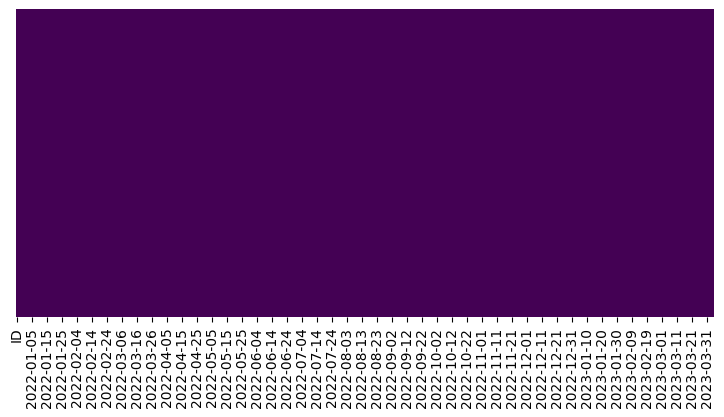

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 결측치를 흰색 선으로 표시해주는 그래프
plt.figure(figsize=(9, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.show()

In [11]:
# 모든 날짜 컬럼(숫자 데이터)만 합쳐서 총 판매량 계산
sales_cols = df.columns[6:]  # 날짜 컬럼들만 선택
df['total_sales'] = df[sales_cols].sum(axis=1)

# 총 판매량 기준 내림차순 정렬 후 상위 5개 출력
top_5 = df.sort_values(by='total_sales', ascending=False).head(5)
print("--- 누적 판매량 TOP 5 제품 정보 ---")
print(top_5[['ID', '대분류', '브랜드', 'total_sales']])

--- 누적 판매량 TOP 5 제품 정보 ---
          ID             대분류         브랜드  total_sales
485      485  B002-C001-0001  B002-00113      3118885
11595  11595  B002-C001-0002  B002-02723      2595146
12336  12336  B002-C001-0002  B002-02920      2535587
4470    4470  B002-C001-0001  B002-01069      2008250
3481    3481  B002-C001-0002  B002-00809      1414800


C:\Users\User\AppData\Local\Temp\ipykernel_36552\768094286.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['total_sales'] = df[sales_cols].sum(axis=1)


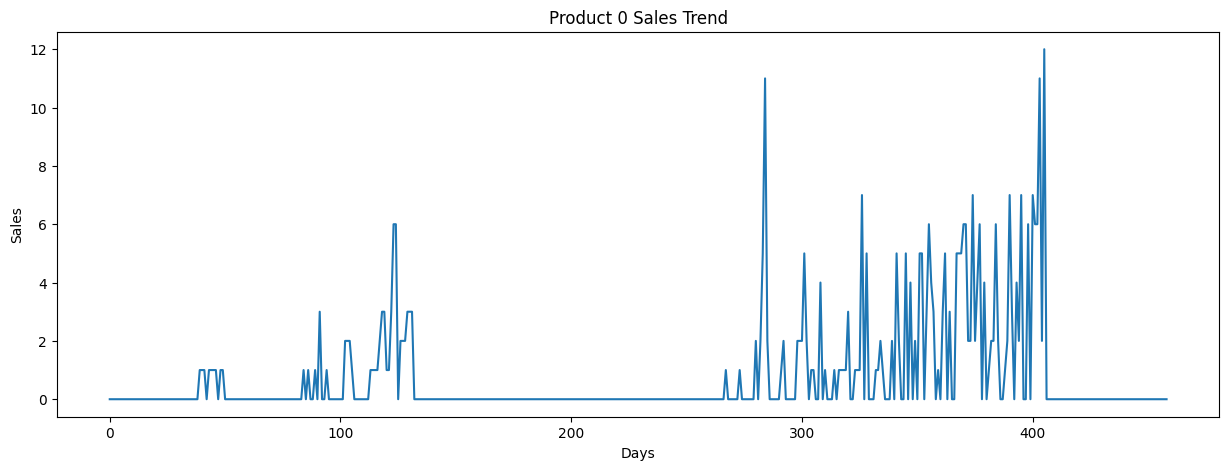

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# 인덱스를 5 대신 6으로 변경 (문자열 컬럼을 완전히 피하기 위함)
# 마지막 'total_sales'도 제외하기 위해 -1까지 슬라이싱
data_to_plot = df.iloc[0, 6:-1].values.astype(float)

plt.plot(data_to_plot) 
plt.title(f"Product {df.iloc[0, 0]} Sales Trend") # 제목에 제품 ID 넣기
plt.xlabel("Days")
plt.ylabel("Sales")
plt.show()

Product 0을 통해 개별 제품의 간헐적 수요(Intermittent Demand) 패턴과 데이터의 노이즈를 확인할 수 있습니다.<br>
그래프의 바닥(0)에 붙어 있는 구간이 전체의 절반 이상을 차지합니다.이는 제품이 매일 팔리지 않는 '비인기 품목'이거나 '재고 부족' 등의 외부 요인이 강하게 작용했음을 뜻합니다. LSTM 같은 모델이 학습할 때, 아무런 패턴 없이 0이 지속되다가 갑자기 값이 튀면 모델이 혼란을 겪을 수 있으니 이에 대한 전처리가 필요함을 알 수 있습니다. 타깃 변수 압축 (로그 변환 & 스케일링), 시계열 노이즈 제거 (이동 평균), 상태 정보 제공 (피처 엔지니어링) 등.

In [13]:
df['ID']

0            0
1            1
2            2
3            3
4            4
         ...  
15885    15885
15886    15886
15887    15887
15888    15888
15889    15889
Name: ID, Length: 15890, dtype: int64

In [14]:
df['ID'].head()

0    0
1    1
2    2
3    3
4    4
Name: ID, dtype: int64

In [15]:
df['제품']

0        B002-00001-00001
1        B002-00002-00001
2        B002-00002-00002
3        B002-00002-00003
4        B002-00003-00001
               ...       
15885    B002-03799-00002
15886    B002-03799-00003
15887    B002-03799-00004
15888    B002-03799-00005
15889    B002-03799-00010
Name: 제품, Length: 15890, dtype: str

In [16]:
df['제품'].head()

0    B002-00001-00001
1    B002-00002-00001
2    B002-00002-00002
3    B002-00002-00003
4    B002-00003-00001
Name: 제품, dtype: str

In [17]:
df['대분류'].head

<bound method NDFrame.head of 0        B002-C001-0002
1        B002-C001-0003
2        B002-C001-0003
3        B002-C001-0003
4        B002-C001-0001
              ...      
15885    B002-C001-0003
15886    B002-C001-0003
15887    B002-C001-0003
15888    B002-C001-0003
15889    B002-C001-0002
Name: 대분류, Length: 15890, dtype: str>

In [18]:
df['중분류']

0        B002-C002-0007
1        B002-C002-0008
2        B002-C002-0008
3        B002-C002-0008
4        B002-C002-0001
              ...      
15885    B002-C002-0008
15886    B002-C002-0008
15887    B002-C002-0008
15888    B002-C002-0008
15889    B002-C002-0004
Name: 중분류, Length: 15890, dtype: str

In [19]:
df['소분류']

0        B002-C003-0038
1        B002-C003-0044
2        B002-C003-0044
3        B002-C003-0044
4        B002-C003-0003
              ...      
15885    B002-C003-0042
15886    B002-C003-0044
15887    B002-C003-0044
15888    B002-C003-0044
15889    B002-C003-0020
Name: 소분류, Length: 15890, dtype: str

In [20]:
df['브랜드']

0        B002-00001
1        B002-00002
2        B002-00002
3        B002-00002
4        B002-00003
            ...    
15885    B002-03799
15886    B002-03799
15887    B002-03799
15888    B002-03799
15889    B002-03799
Name: 브랜드, Length: 15890, dtype: str

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 판매량 데이터만 슬라이싱 (6번 컬럼부터 total_sales 전까지)
sales_data = df.iloc[:, 6:-1]

# 2. 각 행(제품)별로 0이 아닌 첫 번째 값의 인덱스(날짜) 찾기
# 값이 0보다 큰 지점을 불리언으로 만들고, 처음 True가 나오는 위치를 반환합니다.
first_sales_indices = (sales_data > 0).idxmax(axis=1)

# 참고: 만약 모든 날이 0인 제품이 있다면 idxmax는 첫 번째 인덱스를 반환하므로 
# 실제 판매가 일어났는지 한 번 더 체크하는 것이 정확합니다.
has_sales = (sales_data > 0).any(axis=1)
launch_dates = first_sales_indices[has_sales]

# 3. 날짜 형식이 문자열이라면 datetime으로 변환
launch_dates_dt = pd.to_datetime(launch_dates)

신제품 출시 분포 히스토그램

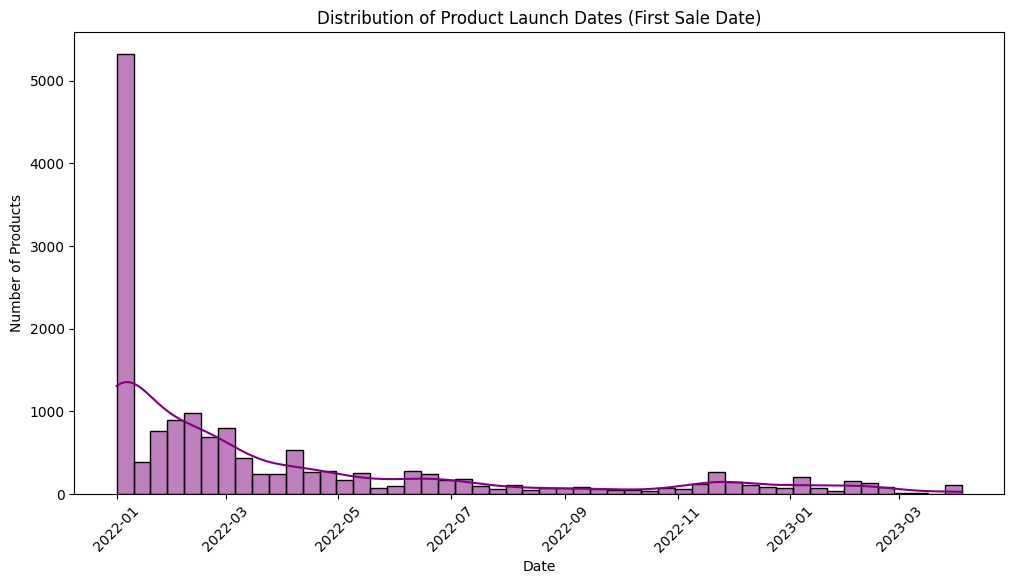

In [22]:
plt.figure(figsize=(12, 6))
sns.histplot(launch_dates_dt, bins=50, kde=True, color='purple')
plt.title("Distribution of Product Launch Dates (First Sale Date)")
plt.xlabel("Date")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()

In [23]:
# 1. 판매량 데이터만 추출 (6번 컬럼부터 마지막 전까지)
sales_only = df.iloc[:, 6:-1]

# 2. 모든 제품의 날짜별 판매 합계 계산 (Series 형태)
daily_total_sales = sales_only.sum(axis=0)

# 3. 인덱스를 datetime 객체로 변환 (요일/월 추출을 위해 필수)
daily_total_sales.index = pd.to_datetime(daily_total_sales.index)

C:\Users\User\AppData\Local\Temp\ipykernel_36552\1300481204.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], y=weekday_sales.values, palette='viridis')


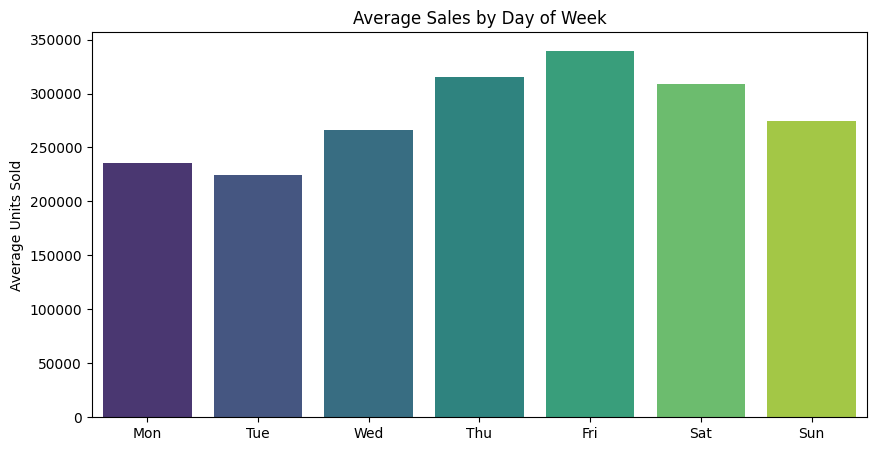

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 요일 추출 (0: 월요일, 6: 일요일)
weekday_sales = daily_total_sales.groupby(daily_total_sales.index.dayofweek).mean()

plt.figure(figsize=(10, 5))
sns.barplot(x=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], y=weekday_sales.values, palette='viridis')
plt.title("Average Sales by Day of Week")
plt.ylabel("Average Units Sold")
plt.show()

전체 제품의 요일별 평균 판매량을 분석한 결과, 금요일에 판매량이 가장 높고 화요일에 가장 낮은 뚜렷한 주간 주기성(Weekly Seasonality)을 확인했습니다. 이는 소비자의 주간 구매 패턴이 존재함을 시사하며, 향후 LSTM 모델 학습 시 요일 정보(0~6)를 추가 피처로 활용할 수 있을 것 같습니다.

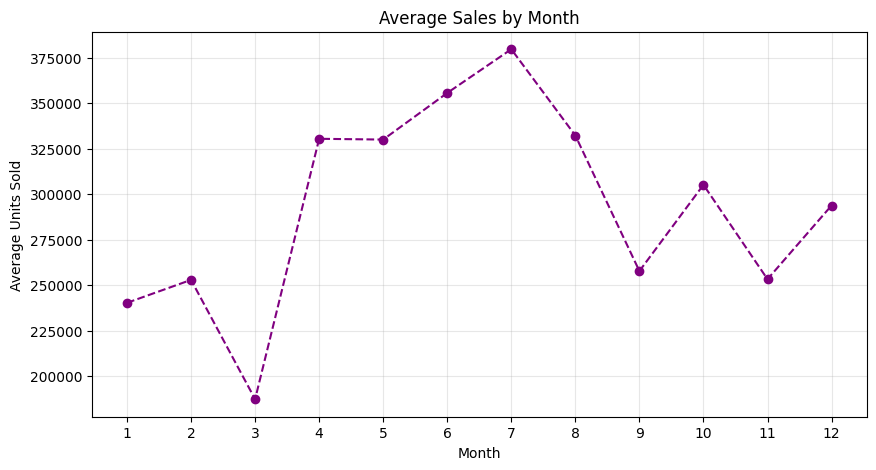

In [25]:
# 월 추출 (1월 ~ 12월)
monthly_sales = daily_total_sales.groupby(daily_total_sales.index.month).mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='purple', linestyle='--')
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.show()

정점은 7월 : 일평균 판매량이 약 38만 건으로 1년 중 가장 높습니다. 6,7,8월이 다른 월보다 평균적으로 판매량이 높은 걸 보니 여름 시즌 특수나 대규모 프로모션이 있었을 가능성이 큽니다. 여름 시즌 특수를 받을 수 있는 제품(선풍기, 에어컨 등)이 판매량을 높여줬음을 추측해볼 수 있습니다.

급감하는 3월: 18만 건 수준으로 뚝 떨어지는데, 이는 개학 시즌이나 특정 소비 비수기 영향일 수 있습니다.

하반기 변동성: 8월 이후 다시 하락했다가 10월과 12월에 반등하는 'N자형' 패턴을 보입니다.

인사이트: 모델이 "지금이 몇 월인가"를 아는 것이 예측에 매우 중요합니다. 7월 데이터라면 평소보다 높게 예측하도록 유도해야합니다.


|**분석 항목**|**발견된 주요 패턴**|**모델링 전략**|
|---|---|---|
|**제품별 트렌드**|0번 제품처럼 판매가 끊겼다 다시 시작되는 '간헐적 수요' 존재|로그 변환(`np.log1p`)으로 변동성 완화|
|**출시일 분포**|2022년 1월에 집중되어 있으나 꾸준히 신제품 유입|'판매 경과일' 피처 생성 검토|
|**요일별 계절성**|**금요일** 피크, 화요일 최저 (주간 주기성 뚜렷)|요일 정보(0~6)를 임베딩 레이어로 학습|
|**월별 계절성**|**7월** 최대, 3월 최소 (연간 주기성 뚜렷)|월(Month) 정보를 피처로 추가||


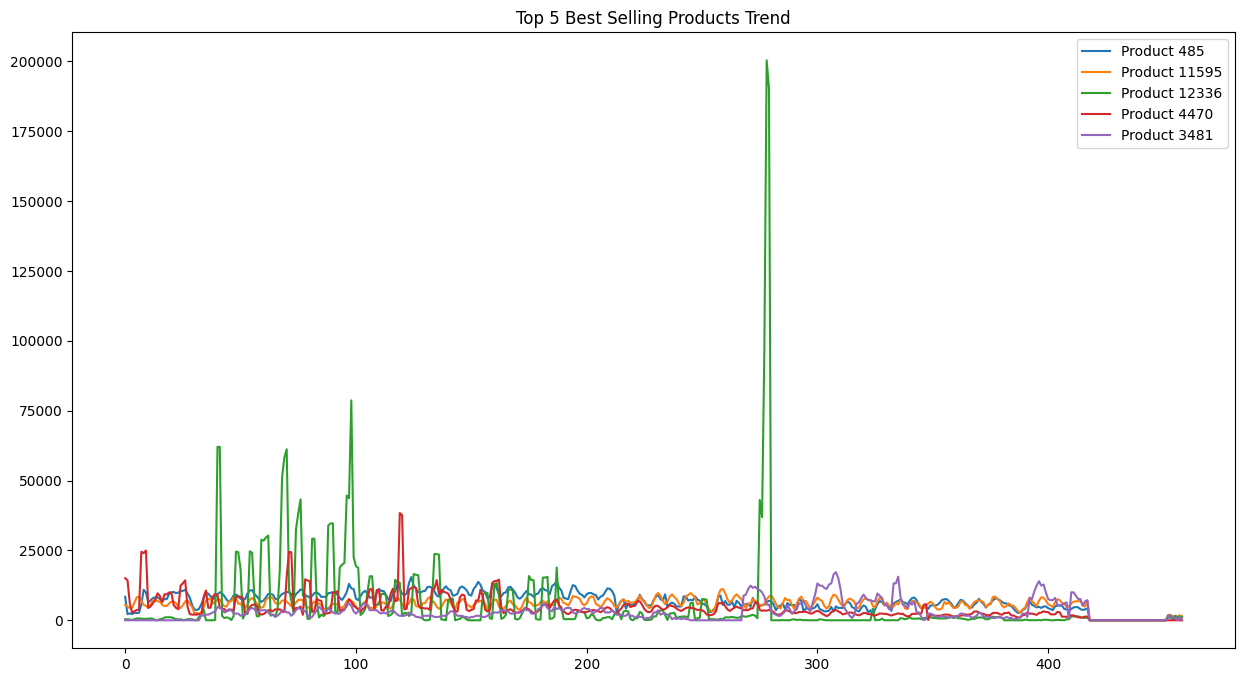

In [27]:
# total_sales 기준 상위 5개 제품 인덱스 추출
top5_indices = df['total_sales'].nlargest(5).index

# 상위 5개 제품 그래프 그리기
plt.figure(figsize=(15, 8))
for idx in top5_indices:
    plt.plot(df.iloc[idx, 6:-1].values, label=f"Product {idx}")
plt.legend()
plt.title("Top 5 Best Selling Products Trend")
plt.show()

270일~280일 지점(대략 2022년 10월경)에 초록색 제품(Product 12336)의 판매량이 20만 건까지 어마어마하게 치솟은 게 보입니다.<br>
이건 일반적인 판매가 아니라 역대급 할인 행사나 특정 이슈가 있었을 확률이 높습니다. 이런 이상치(Outlier)는 나중에 LSTM 모델 등 모델들이 학습할 때 방해가 될 수 있으니 로그 변환 (Log Transformation), 클리핑 (Clipping / Winsorization), 이동 평균 또는 보간법 (Interpolation) 등을 통해 전처리를 해야할 것 같습니다.

In [29]:
# 전체 판매 데이터 중 최대값 찾기
max_idx = df.iloc[:, 6:-1].values.argmax()
row, col = divmod(max_idx, df.iloc[:, 6:-1].shape[1])

best_product_id = df.iloc[row, 0] # ID 컬럼
best_date = df.columns[6 + col]
best_sales = df.iloc[row, 6 + col]

print(f"전체 1위 기록 제품 ID: {best_product_id}")
print(f"기록 달성일: {best_date}")
print(f"판매량: {best_sales}")

전체 1위 기록 제품 ID: 12336
기록 달성일: 2022-10-06
판매량: 200420


이커머스 대형 프로모션으로 인한 판매량 급증으로 추측해볼 수 있을 것 같습니다. Product 12336이 메인 특가 상품이었던 것 같습니다.

시계열 분해

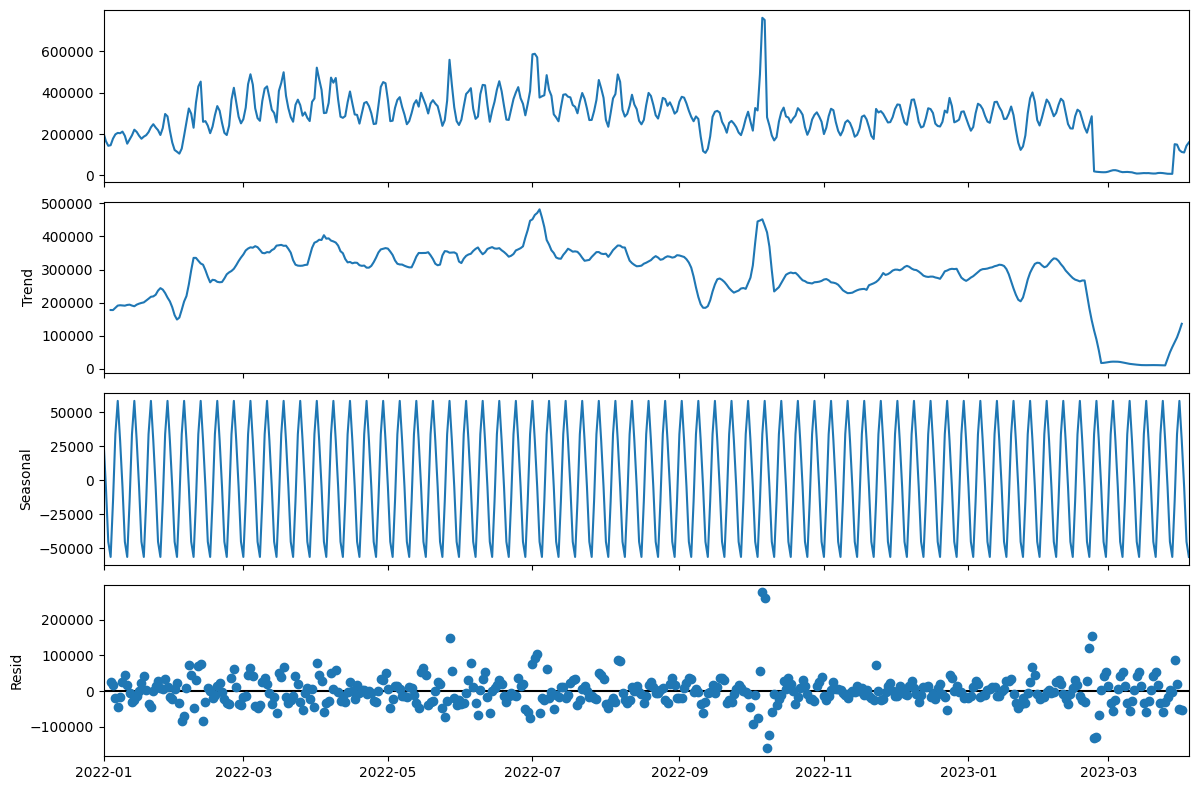

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 주간 단위(period=7)로 분해
decomposition = seasonal_decompose(daily_total_sales, model='additive', period=7)

plt.rcParams['figure.figsize'] = [12, 8]
decomposition.plot()
plt.show()

Trend (추세): 전체적인 판매량의 흐름입니다. 2022년 7월경 정점을 찍고 내려왔다가 10월에 다시 튀는 모습을 보입니다.<br>
Seasonal (계절성): 규칙적인 파동입니다. 아주 일정한 간격으로 오르내리는 걸 보니 요일별 패턴이 매우 뚜렷하다는 것을 알 수 있습니다.<br>
Resid (잔차): 추세나 계절성으로 설명되지 않는 '돌발 변수'입니다. 2022년 10월경에 점들이 위로 크게 튀어 있습니다.위에 그래프에서 확인한 이상치로 볼 수 있습니다.